## Week 1 — Day 1

### Objective
- Load the Online Retail II dataset
- Inspect its structure
- Identify missing values and duplicates    
- Explore numerical distributions
- Create initial sales visualizations
- Generate a correlation heatmap

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [3]:
df = pd.read_csv("../Data/Raw/online_retail_II.csv", low_memory=False)

print("Original dataset shape:", df.shape)
print("\nOriginal columns:")
print(df.columns.tolist())

Original dataset shape: (1067371, 8)

Original columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [4]:
df.sample(10)    

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
843307,564818,22355,CHARLOTTE BAG SUKI DESIGN,16,2011-08-30 12:10:00,1.63,NaN,United Kingdom
533912,537136,79149B,SILICON STAR BULB BLUE,1,2010-12-05 12:42:00,0.42,"12,748.00",United Kingdom
1026018,578786,23356,LOVE HOT WATER BOTTLE,3,2011-11-25 12:02:00,5.95,"13,184.00",United Kingdom
129325,501686,85099B,JUMBO BAG RED WHITE SPOTTY,5,2010-03-18 16:35:00,1.95,NaN,United Kingdom
8179,490074,47504H,ENGLISH ROSE SPIRIT LEVEL,1,2009-12-03 14:39:00,7.78,NaN,United Kingdom
958105,573878,23356,LOVE HOT WATER BOTTLE,6,2011-11-01 13:20:00,5.95,"14,243.00",United Kingdom
16161,490728,10002,INFLATABLE POLITICAL GLOBE,2,2009-12-07 16:40:00,0.85,"16,702.00",United Kingdom
442924,531552,22423,REGENCY CAKESTAND 3 TIER,16,2010-11-09 09:23:00,10.95,"14,626.00",United Kingdom
931972,571797,22549,PICTURE DOMINOES,1,2011-10-19 11:41:00,2.46,NaN,United Kingdom
362753,524522,22551,PLASTERS IN TIN SPACEBOY,12,2010-09-29 13:14:00,1.65,"14,911.00",EIRE


In [5]:
df.dropna(subset=["Description"], inplace=True)

In [6]:
df.sample(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
579126,540848,20696,FLORAL SOFT CAR TOY,1,2011-01-12 09:26:00,3.36,NaN,United Kingdom
190413,507416,21643,ASSORTED TUTTI FRUTTI MIRROR,12,2010-05-09 14:32:00,1.25,"14,678.00",United Kingdom
559313,539300,22756,LARGE YELLOW BABUSHKA NOTEBOOK,1,2010-12-16 17:31:00,1.25,NaN,United Kingdom
174104,505877,79029,GLASS HONEYPOT WASP CATCHER,6,2010-04-26 13:33:00,1.95,"12,921.00",United Kingdom
162696,504902,21955,DOOR MAT UNION JACK GUNS AND ROSES,1,2010-04-18 15:35:00,7.49,"13,286.00",United Kingdom
172668,505732,22514,CHILDS GARDEN SPADE BLUE,6,2010-04-25 15:26:00,2.10,"13,510.00",United Kingdom
691724,550906,79164,BLACK WINE GLASS,240,2011-04-21 12:34:00,0.39,"14,298.00",United Kingdom
896525,569210,23321,SMALL WHITE HEART OF WICKER,10,2011-10-02 11:41:00,1.65,"13,681.00",United Kingdom
973613,575036,23300,GARDENERS KNEELING PAD CUP OF TEA,12,2011-11-08 11:45:00,1.65,"15,249.00",United Kingdom
20471,491043,22145,CHRISTMAS CRAFT HEART STOCKING,1,2009-12-09 09:51:00,4.30,NaN,United Kingdom


In [7]:
print("Unique known customers:", df["Customer ID"].nunique())
print("Total Null Values of Customer ID : ",df["Customer ID"].isnull().sum())

Unique known customers: 5942
Total Null Values of Customer ID :  238625


In [8]:
df.columns = df.columns.str.strip()

df = df.rename(columns={
    "Price": "UnitPrice",
    "Customer ID": "CustomerID"
})

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"],errors="coerce")

df["Invoice"] = df["Invoice"].astype("string")
df["StockCode"] = df["StockCode"].astype("string")

# Concert ID into Int
df["CustomerID"] = pd.to_numeric(df["CustomerID"],errors="coerce").astype("Int64")

df["Description"] = df["Description"].astype("string")
df["Country"] = df["Country"].astype("string")

print(df.dtypes)

Invoice                string
StockCode              string
Description            string
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID              Int64
Country                string
dtype: object


In [9]:
import numpy as np

# Copy standardized source data
sales_df = df.copy()

# Identify guest checkouts and cancelled invoices
sales_df["IsGuestCheckout"] = sales_df["CustomerID"].isna()

sales_df["IsCancelled"] = (
    sales_df["Invoice"]
      .str.upper()
      .str.startswith("C", na=False)
)

# Identify negative-quantity transactions
sales_df["IsReturn"] = sales_df["Quantity"] < 0

# Assign one readable transaction category
sales_df["TransactionType"] = np.select(
    [
        sales_df["IsCancelled"],
        sales_df["IsReturn"]
    ],
    [
        "Cancellation",
        "Return"
    ],
    default="Sale"
)

# Calculate line-level net amount
sales_df["TotalPrice"] = (
    sales_df["Quantity"] * sales_df["UnitPrice"]
)

# Remove exact duplicate source records
original_transaction_columns = [
    "Invoice",
    "StockCode",
    "Description",
    "Quantity",
    "InvoiceDate",
    "UnitPrice",
    "CustomerID",
    "Country"
]

before = len(sales_df)

sales_df = (
    sales_df
      .drop_duplicates(subset=original_transaction_columns)
      .copy()
)

after = len(sales_df)

# Arrange columns
sales_df = sales_df[
    [
        "Invoice",
        "InvoiceDate",
        "CustomerID",
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice",
        "Country",
        "IsGuestCheckout",
        "IsCancelled",
        "IsReturn",
        "TransactionType",
        "TotalPrice"
    ]
]

print("Rows before:", before)
print("Rows after removing duplicates:", after)
print("Removed duplicate rows:", before - after)

print("\nFinal shape:", sales_df.shape)
print("\nFinal columns:")
print(sales_df.columns.tolist())

Rows before: 1062989
Rows after removing duplicates: 1028761
Removed duplicate rows: 34228

Final shape: (1028761, 13)

Final columns:
['Invoice', 'InvoiceDate', 'CustomerID', 'StockCode', 'Description', 'Quantity', 'UnitPrice', 'Country', 'IsGuestCheckout', 'IsCancelled', 'IsReturn', 'TransactionType', 'TotalPrice']


In [43]:
total_rows = len(sales_df)

guest_rate = sales_df["IsGuestCheckout"].mean() * 100
cancel_rate = sales_df["IsCancelled"].mean() * 100
return_rate = sales_df["IsReturn"].mean() * 100

start_date = sales_df["InvoiceDate"].min()
end_date = sales_df["InvoiceDate"].max()
total_days = (end_date - start_date).days + 1

print("\n📈 SALES TRANSACTION STATS")
print("--------------------------")
print(f"   📅 Date range:         {start_date.date()} → {end_date.date()}  ({total_days:,} days)")
print(f"   🧾 Total rows:         {total_rows:,}")
print(f"   💵 Net revenue:        {sales_df['TotalPrice'].sum():,.2f}£")
print(f"   🛒 Unique invoices:    {sales_df['Invoice'].nunique():,}")
print(f"   👥 Active customers:   {sales_df['CustomerID'].nunique():,}")
print(f"   📦 Unique products:    {sales_df['StockCode'].nunique():,}")
print(f"   🚫 Cancellations:      {sales_df['IsCancelled'].sum():,} ({cancel_rate:.2f}%)")
print(f"   ↩️ Returns:            {sales_df['IsReturn'].sum():,} ({return_rate:.2f}%)")
print(f"   👤 Missing CustIDs:    {sales_df['CustomerID'].isna().sum():,} ({guest_rate:.2f}% guest checkouts)")

print("\n📊 TRANSACTION TYPES")
print("--------------------")
print(sales_df["TransactionType"].value_counts())


📈 SALES TRANSACTION STATS
--------------------------
   📅 Date range:         2009-12-01 → 2011-12-09  (739 days)
   🧾 Total rows:         1,028,761
   💵 Net revenue:        18,855,533.70£
   🛒 Unique invoices:    49,353
   👥 Active customers:   5,942
   📦 Unique products:    4,950
   🚫 Cancellations:      19,104 (1.86%)
   ↩️ Returns:            19,863 (1.93%)
   👤 Missing CustIDs:    230,876 (22.44% guest checkouts)

📊 TRANSACTION TYPES
--------------------
TransactionType
Sale            1008897
Cancellation      19104
Return              760
Name: count, dtype: int64


In [11]:
from pathlib import Path

raw_path = Path("../Data/Raw")

sales_df.to_csv(
    raw_path / "retail_sales_transactions.csv",
    index=False
)


In [12]:
sales_df.sample(10)

,Invoice,InvoiceDate,CustomerID,StockCode,Description,Quantity,UnitPrice,Country,IsGuestCheckout,IsCancelled,IsReturn,TransactionType,TotalPrice
35050,492313,2009-12-16 12:09:00,14680,21479,WHITE SKULL HOT WATER BOTTLE,10,3.75,United Kingdom,False,False,False,Sale,37.50
3769,489785,2009-12-02 11:51:00,14653,84670,JAPANESE CROCHETED ANIMAL,24,0.42,United Kingdom,False,False,False,Sale,10.08
97202,498547,2010-02-19 17:16:00,18283,20982,12 PENCILS TALL TUBE SKULLS,1,0.85,United Kingdom,False,False,False,Sale,0.85
868963,566952,2011-09-15 16:37:00,<NA>,21935,SUKI SHOULDER BAG,3,1.63,United Kingdom,True,False,False,Sale,4.89
681914,550138,2011-04-14 14:02:00,12841,22224,WHITE LOVEBIRD LANTERN,4,2.95,United Kingdom,False,False,False,Sale,11.80
698875,551713,2011-05-03 15:12:00,16230,23204,CHARLOTTE BAG APPLES DESIGN,10,0.85,United Kingdom,False,False,False,Sale,8.50
336082,522115,2010-09-12 16:08:00,15796,21257,VICTORIAN SEWING BOX MEDIUM,2,7.95,United Kingdom,False,False,False,Sale,15.90
189443,507380,2010-05-09 11:40:00,13838,22431,WATERING CAN BLUE ELEPHANT,1,1.95,United Kingdom,False,False,False,Sale,1.95
1003075,577061,2011-11-17 14:40:00,14911,22737,RIBBON REEL CHRISTMAS PRESENT,10,1.65,EIRE,False,False,False,Sale,16.50
682865,550204,2011-04-15 10:37:00,<NA>,22668,PINK BABY BUNTING,1,5.79,United Kingdom,True,False,False,Sale,5.79


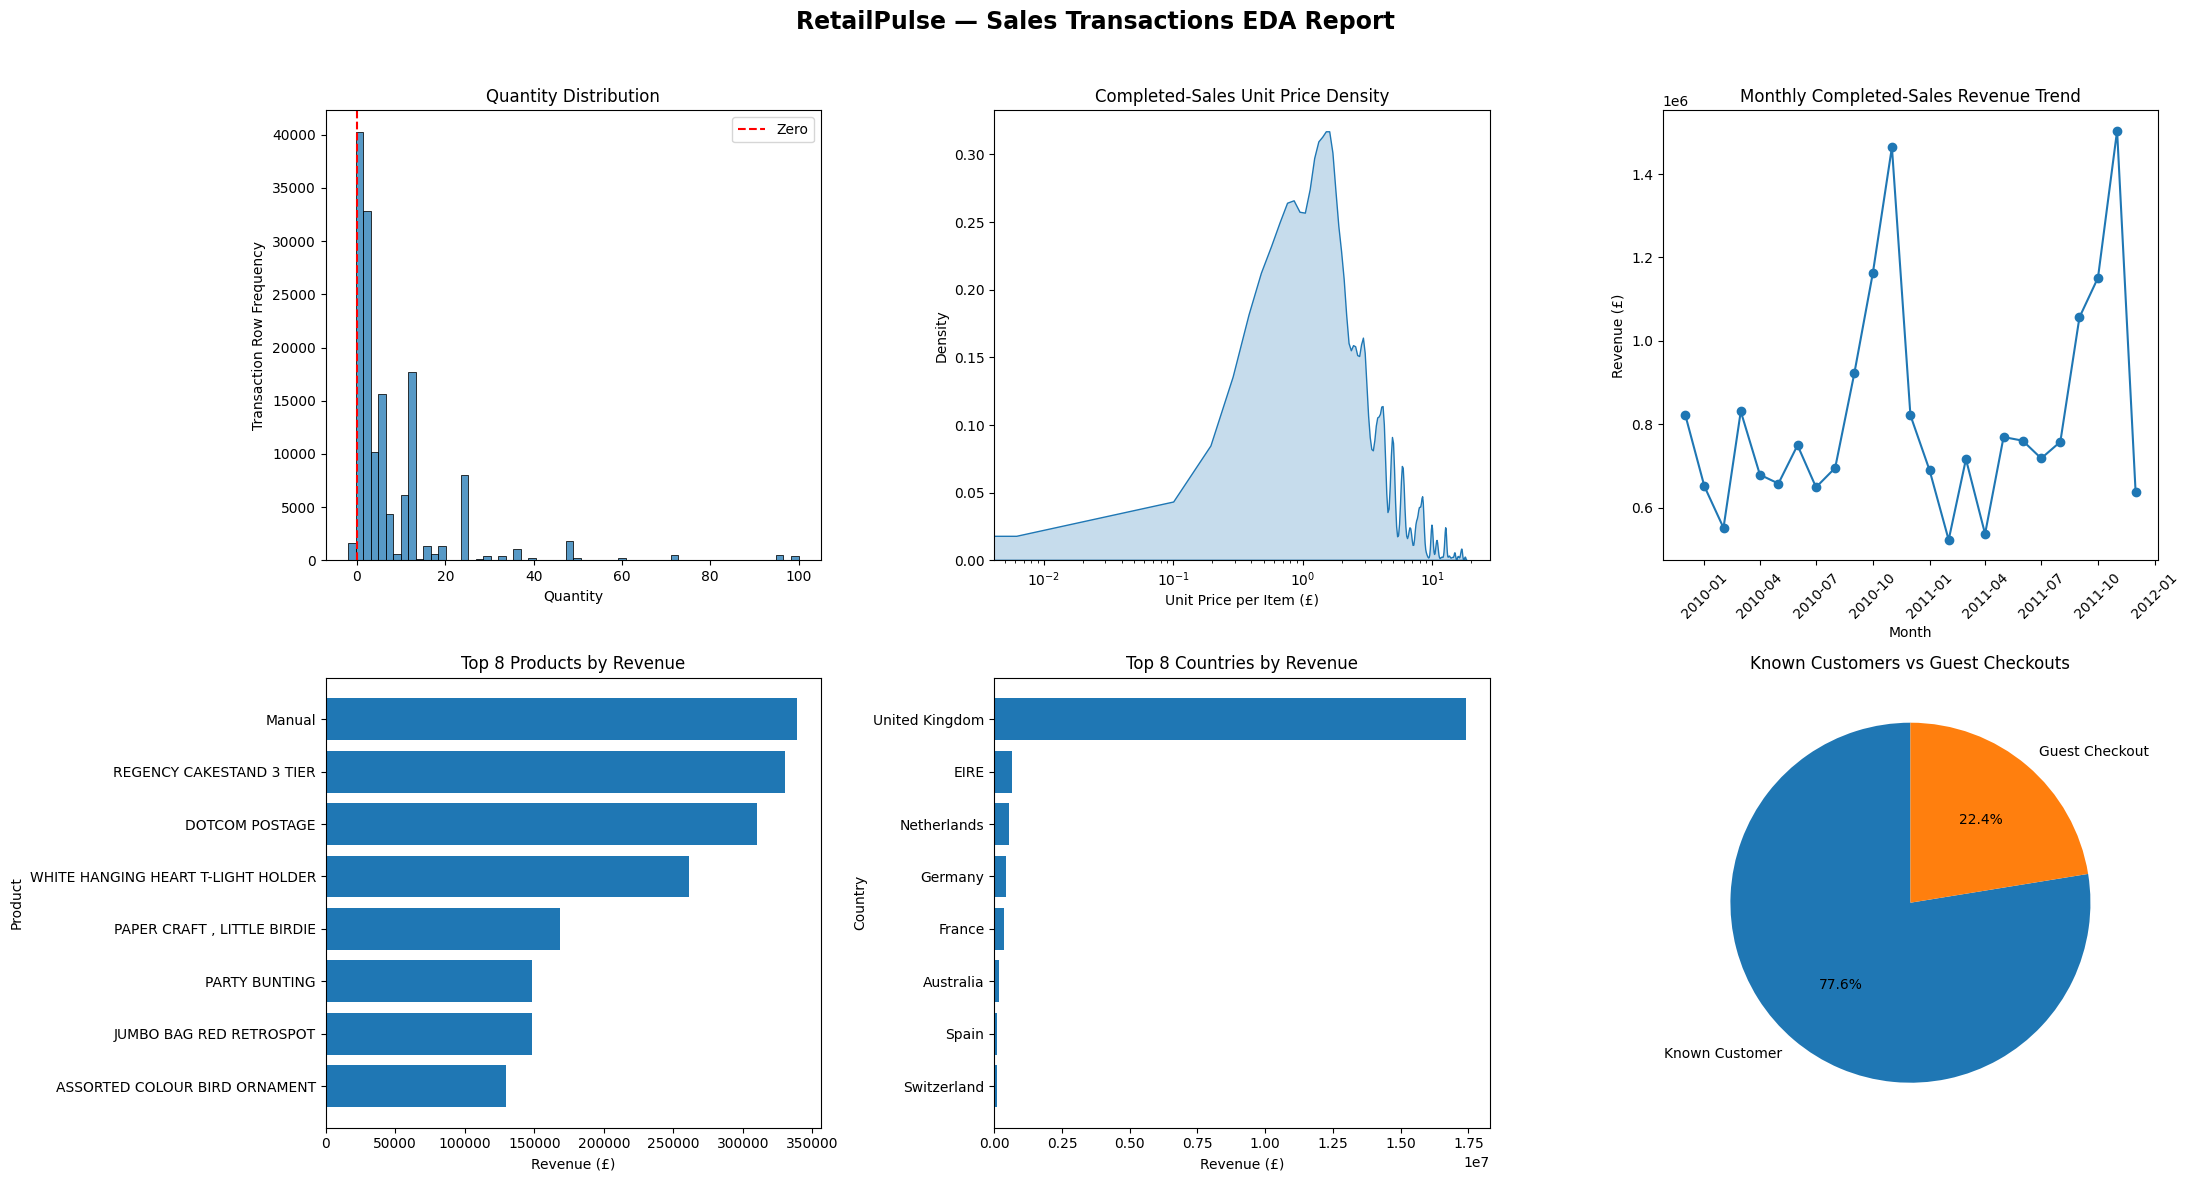

In [21]:

# CHART 1: QUANTITY DISTRIBUTION VALUES

sample_size = min(150_000, len(sales_df))

quantity_sample = sales_df["Quantity"].sample(n=sample_size,random_state=42).dropna()

quantity_low = quantity_sample.quantile(0.01)
quantity_high = quantity_sample.quantile(0.99)

quantity_plot_values = quantity_sample[
    quantity_sample.between(quantity_low, quantity_high)
]


# CHART 2: UNIT PRICE DISTRIBUTION VALUES

# COMPLETED SALES FILTER

completed_sales_mask = (
    (sales_df["Quantity"] > 0)
    & (sales_df["UnitPrice"] > 0)
    & (~sales_df["IsCancelled"])
)

unit_price_values = sales_df.loc[completed_sales_mask,"UnitPrice"].dropna()

price_low = unit_price_values.quantile(0.01)
price_high = unit_price_values.quantile(0.99)

unit_price_plot_values = unit_price_values[
    unit_price_values.between(price_low, price_high)
]

log_bins = np.logspace(np.log10(price_low),np.log10(price_high),50)


# CHART 3: MONTHLY REVENUE VALUES

monthly_revenue = (
    sales_df.loc[completed_sales_mask]
    .groupby(sales_df.loc[completed_sales_mask,"InvoiceDate"].dt.to_period("M")) # Using dt.to_period("M") to group by month
    ["TotalPrice"].sum().sort_index()
)

monthly_revenue.index = monthly_revenue.index.to_timestamp()


# CHART 4: TOP PRODUCTS VALUES

top_products = (
    sales_df.loc[completed_sales_mask].dropna(subset=["Description"])
    .groupby("Description")["TotalPrice"].sum().sort_values(ascending=False).head(8).sort_values()
)


# CHART 5: TOP COUNTRIES VALUES

top_countries = (
    sales_df.loc[completed_sales_mask].dropna(subset=["Country"])
    .groupby("Country")["TotalPrice"].sum().sort_values(ascending=False)
    .head(8).sort_values()
)


# CHART 6: CHECKOUT TYPE VALUES

checkout_type_counts = (sales_df["IsGuestCheckout"].map({
        False: "Known Customer",
        True: "Guest Checkout"
    }).value_counts()
)

# ---------------------------------------------------------
# CREATE MAIN EDA REPORT
# ---------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(22, 12)
)

# 1. QUANTITY DISTRIBUTION

sns.histplot(
    quantity_plot_values,
    bins=60,
    edgecolor="black",
    ax=axes[0, 0]
)

axes[0, 0].axvline(
    x=0,
    linestyle="--",
    label="Zero",
    color="Red"
)

axes[0, 0].set_title("Quantity Distribution")
axes[0, 0].set_xlabel("Quantity")
axes[0, 0].set_ylabel("Transaction Row Frequency")
axes[0, 0].legend()


# 2. UNIT PRICE DISTRIBUTION

sns.kdeplot(
    unit_price_plot_values,
    ax=axes[0, 1],
    fill=True
)

axes[0, 1].set_xscale("log")
axes[0, 1].set_title("Completed-Sales Unit Price Density")
axes[0, 1].set_xlabel("Unit Price per Item (£)")
axes[0, 1].set_ylabel("Density")


# 3. MONTHLY REVENUE TREND

axes[0, 2].plot(monthly_revenue.index , monthly_revenue.values , marker="o")
axes[0, 2].set_title("Monthly Completed-Sales Revenue Trend")
axes[0, 2].set_xlabel("Month")
axes[0, 2].set_ylabel("Revenue (£)")
axes[0, 2].tick_params(axis="x",rotation=45)


# 4. TOP PRODUCTS BY REVENUE

axes[1, 0].barh(top_products.index,top_products.values)
axes[1, 0].set_title("Top 8 Products by Revenue")
axes[1, 0].set_xlabel("Revenue (£)")
axes[1, 0].set_ylabel("Product")


# 5. TOP COUNTRIES BY REVENUE

axes[1, 1].barh(top_countries.index,top_countries.values)
axes[1, 1].set_title("Top 8 Countries by Revenue")
axes[1, 1].set_xlabel("Revenue (£)")
axes[1, 1].set_ylabel("Country")


# 6. KNOWN CUSTOMERS VS GUEST CHECKOUTS

axes[1, 2].pie(
    checkout_type_counts.values,
    labels=checkout_type_counts.index,
    autopct="%1.1f%%",
    startangle=90)

axes[1, 2].set_title("Known Customers vs Guest Checkouts")

# FINAL REPORT SETTINGS

plt.suptitle(
    "RetailPulse — Sales Transactions EDA Report",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.show()

In [ ]:
figure_path = Path("../Reports/Figure")

fig.savefig(figure_path / "sales_transactions_eda_report.png",dpi=300,bbox_inches="tight")

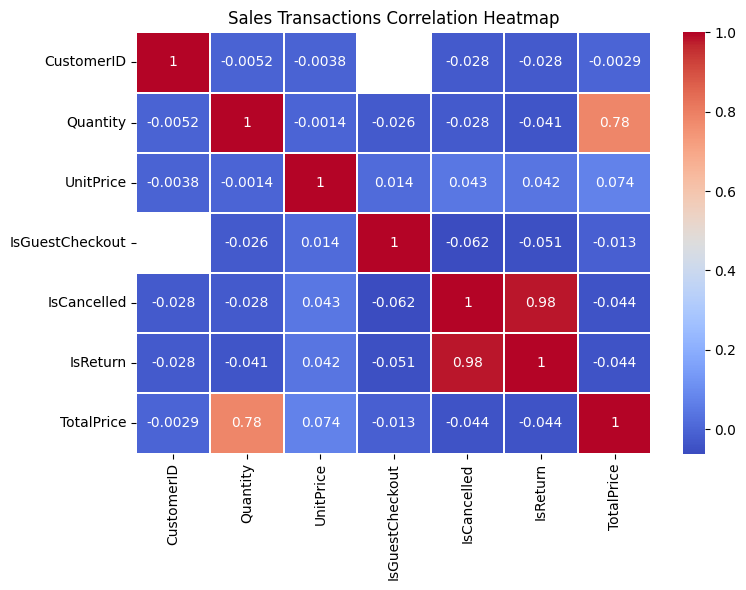

In [35]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(sales_df.corr(numeric_only=True),annot=True,cmap="coolwarm",linewidths=0.07,ax=ax)

ax.set_title("Sales Transactions Correlation Heatmap")

plt.tight_layout()

fig.savefig(figure_path / "Corr_Report.png",dpi=300,)

plt.show()